In [ ]:
import os
os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache")
os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)

os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"
os.environ["CRDS_CONTEXT"] = "jwst_1460.pmap"

from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.svo_fps import SvoFps
from astropy.wcs import WCS
from astropy.io import fits
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc
from dust_extinction.parameter_averages import CCM89




def get_mag(catalog, ww, filtername='f140m' ):
    print(ww.proj_plane_pixel_area())
    
    flux= (catalog['flux_fit_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])

    zeropoint_ab = 3631 * u.Jy  # Default to AB magnitude zero point
 
    if wav < 500:

        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
   
    abmag = -2.5 * np.log10(flux / zeropoint_ab) * u.mag
    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return  vegamag, vegamag_err, abmag, abmag_err


image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}
catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new.fits')
nmatch = catalog['nmatch_bands']
catalog = catalog[nmatch>3]
print(catalog.colnames)


f140m_header = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
f162m_header = fits.getheader(image_filenames['f162m'], ext=('SCI', 1))
f182m_header = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
f210m_header = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
f335m_header = fits.getheader(image_filenames['f335m'], ext=('SCI', 1))
f360m_header = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
f410m_header = fits.getheader(image_filenames['f410m'], ext=('SCI', 1))
f480m_header = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))
f560w_header = fits.getheader(image_filenames['f560w'], ext=('SCI', 1))
f770w_header = fits.getheader(image_filenames['f770w'], ext=('SCI', 1))
f1000w_header = fits.getheader(image_filenames['f1000w'], ext=('SCI', 1))
f1280w_header = fits.getheader(image_filenames['f1280w'], ext=('SCI', 1))
f2100w_header = fits.getheader(image_filenames['f2100w'], ext=('SCI', 1))



f140m_mag = get_mag(catalog, WCS(f140m_header), filtername='f140m')
f162m_mag = get_mag(catalog, WCS(f162m_header), filtername='f162m')
f182m_mag = get_mag(catalog, WCS(f182m_header), filtername='f182m')
f210m_mag = get_mag(catalog, WCS(f210m_header), filtername='f210m')
f335m_mag = get_mag(catalog, WCS(f335m_header), filtername='f335m')
f360m_mag = get_mag(catalog, WCS(f360m_header), filtername='f360m')
f405n_mag = get_mag(catalog, WCS(f405n_header), filtername='f405n')
f410m_mag = get_mag(catalog, WCS(f410m_header), filtername='f410m')
f480m_mag = get_mag(catalog, WCS(f480m_header), filtername='f480m')
f560w_mag = get_mag(catalog, WCS(f560w_header), filtername='f560w')
f770w_mag = get_mag(catalog, WCS(f770w_header), filtername='f770w')
f1000w_mag = get_mag(catalog, WCS(f1000w_header), filtername='f1000w')
f1280w_mag = get_mag(catalog, WCS(f1280w_header), filtername='f1280w')
f2100w_mag = get_mag(catalog, WCS(f2100w_header), filtername='f2100w')

f187n_header = fits.getheader(image_filenames['f187n'], ext=('SCI', 1))
f187n_mag = get_mag(catalog, WCS(f187n_header), filtername='f187n')


num_sources = len(catalog)

from dust_extinction.averages import RL85_MWGC, CT06_MWGC
from dust_extinction.parameter_averages import CCM89
import astropy.constants as const

ext = CT06_MWLoc()
def plot_extvec_cmd(ax, color1, mag1, ext=RL85_MWGC(), extvec_scale=200, start=None,
                    color='y', head_width=0.5, color1_data=None, mag1_data=None, label=None, fontsize=15):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(mag1[0])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    print(w1,w2,w3)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3)
    print(e_1, e_2, e_3)
    if start == None:
        mean_color1 = np.nanmean(color1_data)
        mean_mag1 = np.nanmean(mag1_data)
        std_color1 = np.nanstd(color1_data)
        std_mag1 = np.nanstd(mag1_data)
        if e_1 - e_2 < 0:
            std_color1 *= -1
        
    
        start2 = (mean_color1 + 2*std_color1, mean_mag1 + 2*std_mag1)
    else:
        start2 = start
    
    # Strip units for plotting if present
    if hasattr(start2[0], 'value'):
        start2_x = start2[0].value
        start2_y = start2[1].value
    else:
        start2_x = start2[0]
        start2_y = start2[1]

    ax.annotate(f'$A_V={extvec_scale}$', xy=(start2_x + (e_1 - e_2), start2_y + e_3),
                xytext=(start2_x, start2_y), fontsize=15,
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    if label is not None:
        ax.plot([], [], color=color, marker='>', markersize=8,
                label=f'{label}', linestyle='-', linewidth=2)

    else:
        ax.plot([], [], color=color, marker='>', markersize=8,
                linestyle='-', linewidth=2)

imgsavedir = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/plots/cmds/'
mags = {
    'f140m': f140m_mag,
    'f162m': f162m_mag,
    'f182m': f182m_mag,
    'f187n': f187n_mag,
    'f210m': f210m_mag,
    'f335m': f335m_mag,
    'f360m': f360m_mag,
    'f405n': f405n_mag,
    'f410m': f410m_mag,
    'f480m': f480m_mag,
    'f560w': f560w_mag,
    'f770w': f770w_mag,
    'f1000w': f1000w_mag,
    'f1280w': f1280w_mag,
    'f2100w': f2100w_mag,
}
filter_names = list(mags.keys())

['skycoord_ref', 'skycoord_ref_filtername', 'sep_f140m', 'id_f140m', 'skycoord_f140m', 'flux_fit_f140m', 'flux_err_f140m', 'mask_f140m', 'qfit_f140m', 'cfit_f140m', 'local_bkg_f140m', 'roundness1_f140m', 'roundness2_f140m', 'sharpness_f140m', 'from_sat_catalog_f140m', 'std_ra_f140m', 'std_dec_f140m', 'nmatch_f140m', 'nmatch_good_f140m', 'flux_err_prop_f140m', 'sep_f162m', 'id_f162m', 'skycoord_f162m', 'flux_fit_f162m', 'flux_err_f162m', 'mask_f162m', 'qfit_f162m', 'cfit_f162m', 'local_bkg_f162m', 'roundness1_f162m', 'roundness2_f162m', 'sharpness_f162m', 'from_sat_catalog_f162m', 'std_ra_f162m', 'std_dec_f162m', 'nmatch_f162m', 'nmatch_good_f162m', 'flux_err_prop_f162m', 'sep_f182m', 'id_f182m', 'skycoord_f182m', 'flux_fit_f182m', 'flux_err_f182m', 'mask_f182m', 'qfit_f182m', 'cfit_f182m', 'local_bkg_f182m', 'roundness1_f182m', 'roundness2_f182m', 'sharpness_f182m', 'from_sat_catalog_f182m', 'std_ra_f182m', 'std_dec_f182m', 'nmatch_f182m', 'nmatch_good_f182m', 'flux_err_prop_f182m', 's

Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


7.525093724479512e-11 deg2


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-06T14:19:06.870' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.194' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.220336 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512569.543 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/f

7.52790883669383e-11 deg2
7.52510476872822e-11 deg2
7.52514718037244e-11 deg2


...

Set DATE-AVG to '2025-05-06T16:59:22.421' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2024-09-08T11:22:58.102' from MJD-AVG.
Set DATE-END to '2024-09-08T12:35:44.015' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.810003 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291940033.618 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2024-09-08T11:31:04.265' from MJD-AVG.
Set DATE-END to '2024-09-08T12:43:52.463' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.803760 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291894033.527 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


9.49145905084584e-10 deg2
9.491458943030916e-10 deg2
9.49145885655769e-10 deg2


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2024-09-08T11:39:49.277' from MJD-AVG.
Set DATE-END to '2024-09-08T12:52:42.510' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.797166 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291845460.779 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2024-09-08T11:47:44.336' from MJD-AVG.
Set DATE-END to '2024-09-08T13:00:37.070' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.791203 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291801554.144 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2024-09-08T11:55:48.768' from MJD-AVG.
Set DATE-END to '2024-09-08T13:08:42.701' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.785099 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291756623.231 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '

9.491458757317268e-10 deg2
7.524574264515582e-11 deg2


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


color1: ('f140m', 'f210m') mag1: ('f140m',)
w_color1_1: 1.4 um w_color1_2: 2.1 um w_mag1: 1.4 um
wav1_short, wav2_short 1.4 2.1
0.7142857142857143 0.47619047619047616
Best n_components (BIC): 5
high_av_cut: 1.9528971841073863
Best n_components (BIC): 3


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(


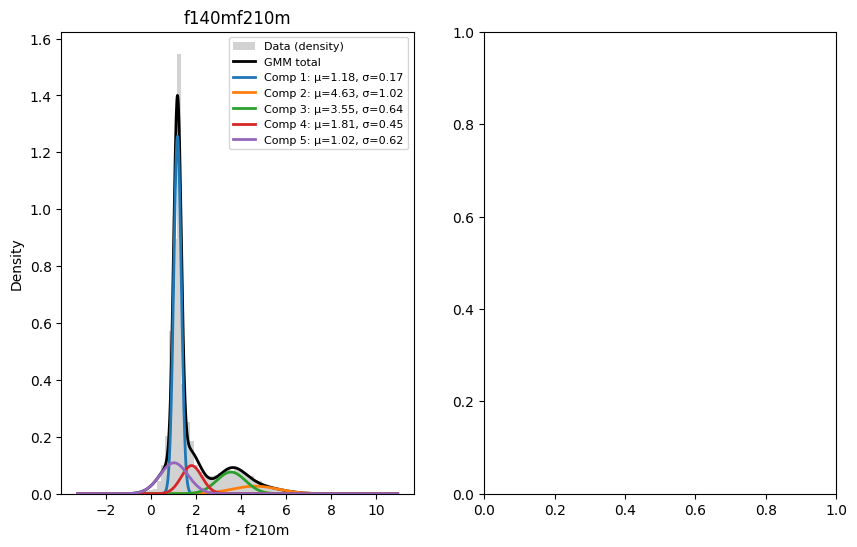

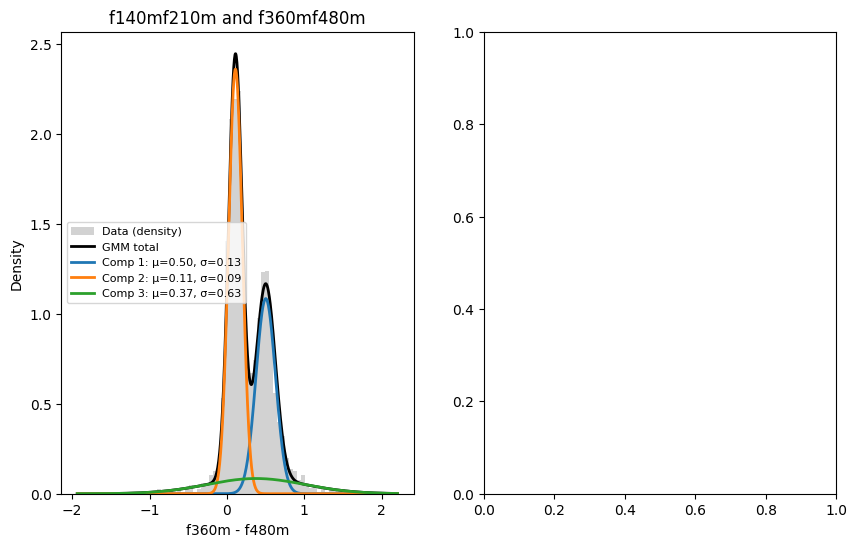

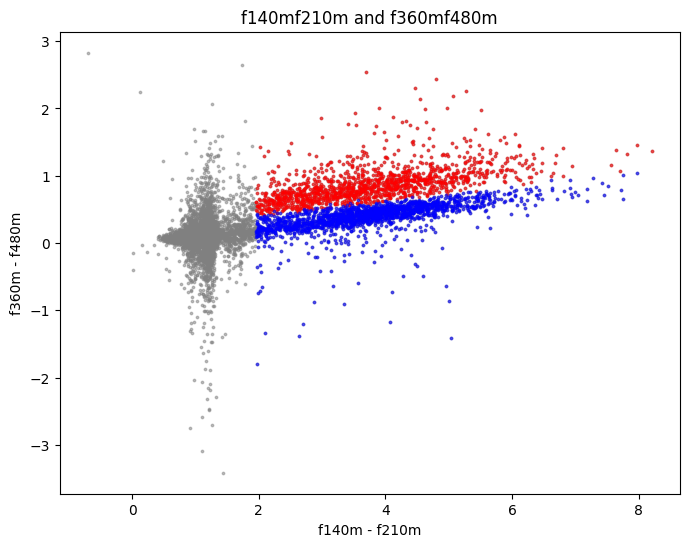

color1: ('f182m', 'f210m') mag1: ('f182m',)
w_color1_1: 1.82 um w_color1_2: 2.1 um w_mag1: 1.82 um
wav1_short, wav2_short 1.82 2.1
0.5494505494505494 0.47619047619047616
Best n_components (BIC): 3
high_av_cut: 0.40110038768910466
Best n_components (BIC): 3


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(


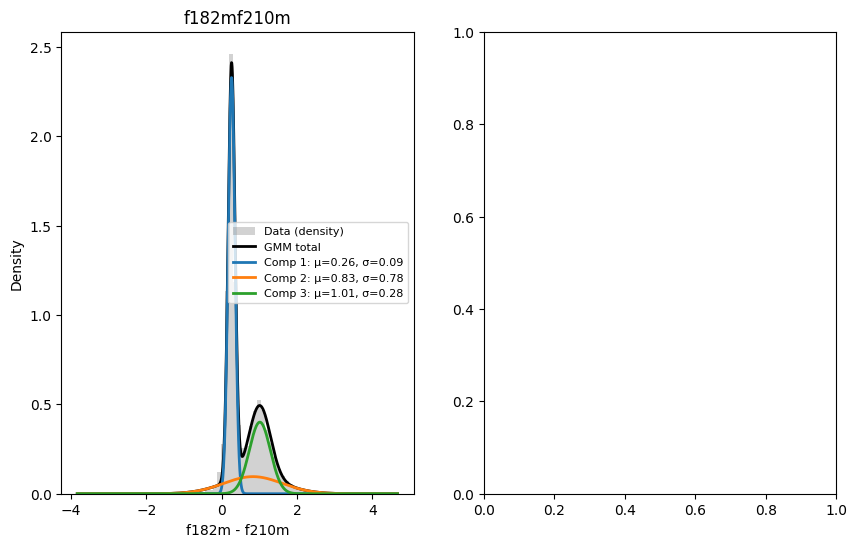

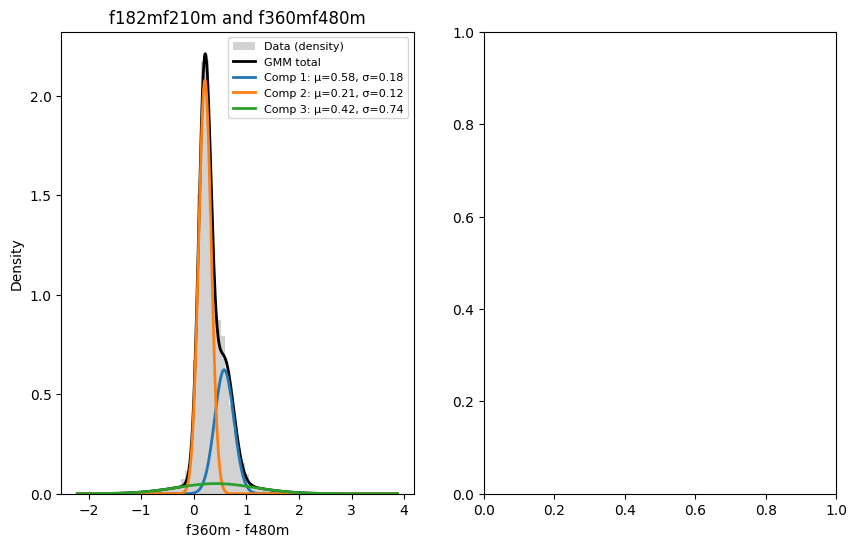

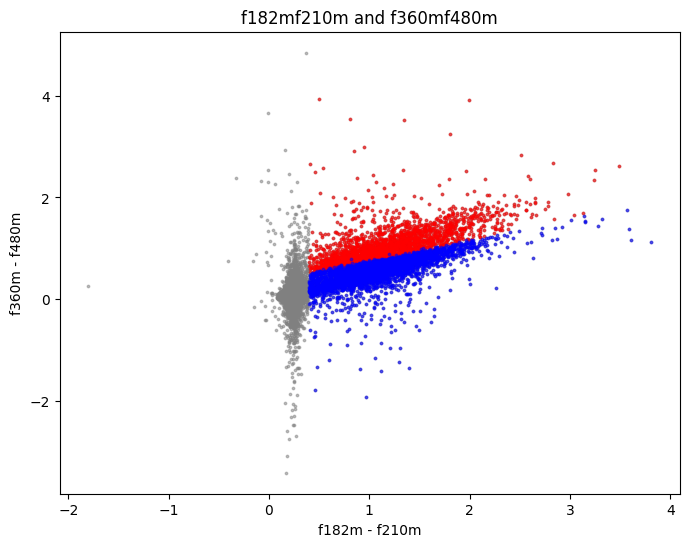

In [ ]:
from astropy.table import Table
import crds
from sklearn.mixture import GaussianMixture
import itertools
import matplotlib.pyplot as plt
import numpy as np

parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
m_init = parsec_av0['col4']  
parsec_av0 = parsec_av0[m_init<300]              
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']

F140Mmag_av0 = parsec_av0['col39'] + 5*np.log10(5400)-5
F162Mmag_av0 = parsec_av0['col40']+ 5*np.log10(5400)-5
F182Mmag_av0 = parsec_av0['col41']+ 5*np.log10(5400)-5
F210Mmag_av0 = parsec_av0['col42']+ 5*np.log10(5400)-5
F335Mmag_av0 = parsec_av0['col45']+ 5*np.log10(5400)-5
F360Mmag_av0 = parsec_av0['col46']+ 5*np.log10(5400)-5
F410Mmag_av0 = parsec_av0['col47']+ 5*np.log10(5400)-5
F480Mmag_av0 = parsec_av0['col50']+ 5*np.log10(5400)-5

age_idx = logage_av0 == 6
idx_01msun = np.argmin(np.abs(mass_av0[age_idx]-0.1))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx]-20))

parsec_mags = {
    'f140m': F140Mmag_av0,
    'f162m': F162Mmag_av0,
    'f182m': F182Mmag_av0,
    'f210m': F210Mmag_av0,
    'f335m': F335Mmag_av0,
    'f360m': F360Mmag_av0,
    'f410m': F410Mmag_av0,
    'f480m': F480Mmag_av0,
}




def get_av(color, mag, ext=None, color1=('f140m', 'f162m'), mag1=('f140m',), isochrone_line_params=None):
    # Get the slope and intercept of the isochrone line
    m_iso, b_iso = isochrone_line_params
    print('color1:', color1, 'mag1:', mag1)

    # Get the extinction vector components
    w_color1_1 = int(color1[0][1:-1])/100*u.um
    w_color1_2 = int(color1[1][1:-1])/100*u.um
    w_mag1 = int(mag1[0][1:-1])/100*u.um
    print('w_color1_1:', w_color1_1, 'w_color1_2:', w_color1_2, 'w_mag1:', w_mag1)

    e_color1_1 = ext(1/w_color1_1)
    e_color1_2 = ext(1/w_color1_2)
    e_mag1 = ext(1/w_mag1)

    # get the contact to the isochrone line along the extinction vector
    # the extinction vector can be represented as a line with slope m_ext = e_mag1 / (e_color1_1 - e_color1_2) and passing through the point (color, mag)
    m_ext = e_mag1 / (e_color1_1 - e_color1_2)
    b_ext = mag - m_ext * color

    # find the intersection of the isochrone line and the extinction vector
    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso

    # calculate A_V as the distance from (color, mag) to (x_int, y_int) along the extinction vector
    av = (mag - y_int) / ext(1/w_mag1)
    av[av < 0] = 0
    return av


def gaussian_decomposition(color, color_label, title=None, n_components=None):
    
    x = np.asarray(color)
    x = x[np.isfinite(x)].reshape(-1, 1)
    
    n_components_grid = range(1, 6)
    if n_components is None:
        
        models, bics, labels, probs = [], [], [], []
        for k in n_components_grid:
            gmm_k = GaussianMixture(n_components=k, random_state=42)
            gmm_k.fit(x)
            label = gmm_k.predict(x)
            prob = gmm_k.predict_proba(x)
            models.append(gmm_k)
            bics.append(gmm_k.bic(x))
            labels.append(label)
            probs.append(prob)


        gmm = models[np.argmin(bics)]
        probs_best = probs[np.argmin(bics)]
        print(f"Best n_components (BIC): {gmm.n_components}")

    else:

        gmm = GaussianMixture(n_components=n_components, random_state=42)
        gmm.fit(x)
        probs_best = gmm.predict_proba(x)

    # Evaluate total PDF and each component PDF
    xgrid = np.linspace(x.min(), x.max(), 1000).reshape(-1, 1)
    logprob = gmm.score_samples(xgrid)
    pdf = np.exp(logprob)
    resp = gmm.predict_proba(xgrid)
    pdf_components = resp * pdf[:, None]

    # Plot histogram + GMM decomposition
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111)
    ax.hist(x.ravel(), bins=80, density=True, alpha=0.35, color='gray', label='Data (density)')
    ax.plot(xgrid, pdf, 'k-', lw=2, label='GMM total')

    for i in range(gmm.n_components):
        ax.plot(
            xgrid, pdf_components[:, i],
            lw=2, label=f'Comp {i+1}: μ={gmm.means_[i,0]:.2f}, σ={np.sqrt(gmm.covariances_[i,0,0]):.2f}'
        )
    ax.set_xlabel(f'{color_label[0]} - {color_label[1]}')
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend(fontsize=8)

    min_component = np.argmin(gmm.means_[:, 0])
    max_component = np.argmax(gmm.means_[:, 0])

    # get the cross section of the two components
    cross_section = np.max(np.where(pdf_components[:, min_component] > pdf_components[:, max_component])[0])



    return gmm, xgrid[cross_section]

def make_sample(filters_for_color_short, filters_for_color_long):


    num_cases = (len(filters_for_color_short)-1) * (len(filters_for_color_long)-1)
    class_table = np.ones((len(catalog), num_cases)) * np.nan

    # get A_V estimates first

    #av_estimates = np.ones(num_sources) * np.nan

  
    """
    for f1_short in filters_for_color_short[:2]:
        f2_short = filters_for_color_short[2]
        filt_color_short = (f1_short, f2_short)
        
        isochrone_x_start = parsec_mags[f1_short][age_idx][idx_01msun] - parsec_mags[f2_short][age_idx][idx_01msun]
        isochrone_x_end = parsec_mags[f1_short][age_idx][idx_20msun] - parsec_mags[f2_short][age_idx][idx_20msun]
        isocrhone_y_start = parsec_mags[f1_short][age_idx][idx_01msun]
        isocrhone_y_end = parsec_mags[f1_short][age_idx][idx_20msun]

        color_slope = (isocrhone_y_end - isocrhone_y_start) / (isochrone_x_end - isochrone_x_start)
        color_intercept = isocrhone_y_start - color_slope * isochrone_x_start

        color_short = mags[f1_short][0] - mags[f2_short][0]

        av_estimate = get_av(color_short.value, mags[f1_short][0].value, ext=CT06_MWLoc(), color1=filt_color_short, mag1=(f1_short,), isochrone_line_params=(color_slope, color_intercept))
        finite_idx_av = np.isfinite(av_estimate)
        av_estimates[finite_idx_av] = av_estimate[finite_idx_av]
    """

    # flags for whether the source is in the upper or lower component of the GMM fit to the color distribution
    flag_selected_upper = np.zeros(len(catalog), dtype=bool)
    flag_selected_lower = np.zeros(len(catalog), dtype=bool)

    idx_tab =0
    for f1_short in filters_for_color_short[:2]:
        f2_short = filters_for_color_short[2]
        filt_color_short = (f1_short, f2_short)
        
        isochrone_x_start = parsec_mags[f1_short][age_idx][idx_01msun] - parsec_mags[f2_short][age_idx][idx_01msun]
        isochrone_x_end = parsec_mags[f1_short][age_idx][idx_20msun] - parsec_mags[f2_short][age_idx][idx_20msun]
        isocrhone_y_start = parsec_mags[f1_short][age_idx][idx_01msun]
        isocrhone_y_end = parsec_mags[f1_short][age_idx][idx_20msun]

        color_slope = (isocrhone_y_end - isocrhone_y_start) / (isochrone_x_end - isochrone_x_start)
        color_intercept = isocrhone_y_start - color_slope * isochrone_x_start

        color_short = mags[f1_short][0] - mags[f2_short][0]

        av_estimate = get_av(color_short.value, mags[f1_short][0].value, ext=CT06_MWLoc(), color1=filt_color_short, mag1=(f1_short,), isochrone_line_params=(color_slope, color_intercept))
        for f1_long in filters_for_color_long[:1]:
            filt_color_short = (f1_short, f2_short)
            wav1_short = float(f1_short[1:-1])/100
            wav2_short = float(f2_short[1:-1])/100
            print('wav1_short, wav2_short', wav1_short, wav2_short)
            print(1/wav1_short, 1/wav2_short)
            filt_mag1 = f1_short
            color_short = mags[f1_short][0] - mags[f2_short][0]
            mag1 = mags[f1_short][0]

            gmm_short = gaussian_decomposition(color_short, filt_color_short, title=''.join(filt_color_short))[0]

            gmm_short_argmin = np.argmin(gmm_short.means_[:, 0])
            #labels = gmm.predict(X)
            #probs = gmm.predict_proba(X)
            #p0 = probs[:,0]
            #p1 = probs[:,1]
          
            # color boundary for low dust extinction and high dust exticntion 1.5sigma
            high_av_cut = gmm_short.means_[gmm_short_argmin,0] + 1.5 * np.sqrt(gmm_short.covariances_[gmm_short_argmin,0,0])

        
            print('high_av_cut:',high_av_cut)




            f2_long = filters_for_color_long[1]
            filt_color_long = (f1_long, f2_long)
            wav1_long = float(f1_long[1:-1])/100
            wav2_long = float(f2_long[1:-1])/100
            color_long = mags[f1_long][0] - mags[f2_long][0]
            color_long_dereddened = color_long.value - av_estimate * (ext(1/wav1_long) - ext(1/wav2_long))
            high_av_idx = np.where(color_short.value > high_av_cut)[0]


            # use GMM
            gmm, boundary_long = gaussian_decomposition(color_long_dereddened[high_av_idx], filt_color_long, title=f"{''.join(filt_color_short)} and {''.join(filt_color_long)}")
           # gmm_argmin = np.argmin(gmm.means_[:, 0])
           # gmm_argmax = np.argmax(gmm.means_[:, 0])
           # print('gmm_argmin', gmm_argmin, 'gmm_argmax', gmm_argmax)
           # print('minmax',np.min(gmm.means_[:, 0]), np.max(gmm.means_[:, 0]))
           # probs_upper = probs[:, gmm_argmax]
           # probs_lower = probs[:, gmm_argmin]
            idx_upper = np.where(color_long_dereddened[high_av_idx] >boundary_long)
            idx_lower = np.where(color_long_dereddened[high_av_idx] < boundary_long)
            
            """
            gmm_argmin = np.argmin(gmm.means_[:, 0])
            gmm_argmax = np.argmax(gmm.means_[:, 0])
            color_mean_upper = gmm.means_[gmm_argmax, 0]
            color_mean_lower = gmm.means_[gmm_argmin, 0]
            color_std_upper = np.sqrt(gmm.covariances_[gmm_argmax, 0, 0])
            color_std_lower = np.sqrt(gmm.covariances_[gmm_argmin, 0, 0])

            idx_upper = np.where(color_long_dereddened[high_av_idx] > color_mean_upper-color_std_upper) 
            idx_lower = np.where(color_long_dereddened[high_av_idx] < color_mean_lower + color_std_lower)
            """
            #check idx_upper and idx_lower in the color-color diagram
            fig, ax = plt.subplots(figsize=(8, 6))
            ax.scatter(color_short, color_long, c='gray', s=3, alpha=0.5)
            ax.scatter(color_short[high_av_idx][idx_upper], color_long[high_av_idx][idx_upper], c='red', s=3, alpha=0.5)
            ax.scatter(color_short[high_av_idx][idx_lower], color_long[high_av_idx][idx_lower], c='blue', s=3, alpha=0.5)
            ax.set_xlabel(f'{filt_color_short[0]} - {filt_color_short[1]}')
            ax.set_ylabel(f'{filt_color_long[0]} - {filt_color_long[1]}')
            plt.title(f"{''.join(filt_color_short)} and {''.join(filt_color_long)}")
            plt.show()

            class_table[high_av_idx[idx_upper], idx_tab] = 1
            class_table[high_av_idx[idx_lower], idx_tab] = -1

            idx_tab += 1
            
            
    return class_table
            



            
class_table = make_sample(['f140m', 'f182m', 'f210m'], [ 'f360m', 'f480m'])






    









In [ ]:
def get_mass(color, mag, isochrone_color, isochrone_mag, mass_iso, assumed_imf_slope=-2.35, ext=RL85_MWGC(), color1=('f140m', 'f162m'), mag1=('f140m',), isochrone_line_params=(color_slope, color_intercept)):
    from shapely.geometry import LineString

    # the extinction vector can be represented as a line with slope m_ext = e_mag1 / (e_color1_1 - e_color1_2) and passing through the point (color, mag)
    w_color1_1 = int(color1[0][1:-1])/100*u.um
    w_color1_2 = int(color1[1][1:-1])/100*u.um
    w_mag1 = int(mag1[0][1:-1])/100*u.um
    e_color1_1 = ext(1/w_color1_1)
    e_color1_2 = ext(1/w_color1_2)
    e_mag1 = ext(1/w_mag1)
    m_ext = e_mag1 / (e_color1_1 - e_color1_2)
    b_ext = mag - m_ext * color 
    # find the intersections with the each line segment of the isochrone data points
    isochrone_curve = LineString(np.column_stack((isochrone_color, isochrone_mag)))

    min_color = np.nanmin(color)
    min_mag = np.nanmin(mag)
    max_color = np.nanmax(color)
    max_mag = np.nanmax(mag)
    masses = []
    for c, m in zip(color, mag):
        if np.isnan(c) or np.isnan(m):
            continue
        ext_line = LineString([(min_color, m_ext*min_color + b_ext), (max_color, m_ext*max_color + b_ext)])
        intersections = isochrone_curve.intersection(ext_line)
        if intersections.geom_type == "Point":
            x_int, y_int = intersections.x, intersections.y
            # find the closest point in the isochrone data to the intersection point
            distances = np.sqrt((isochrone_color - x_int)**2 + (isochrone_mag - y_int)**2)
            closest_idx = np.argmin(distances)
            mass_estimate = mass_iso[closest_idx]
        # if there are multiple intersections, sample one of them based on the probability which is derived from assumed IMF slope
        elif intersections.geom_type == "MultiPoint":
            mass_estimates = []
            for p in intersections.geoms:
                x_int, y_int = p.x, p.y
                distances = np.sqrt((isochrone_color - x_int)**2 + (isochrone_mag - y_int)**2)
                closest_idx = np.argmin(distances)
                mass_estimate = mass_iso[closest_idx]
                mass_estimates.append(mass_estimate)
            probabilities = np.array(mass_estimates)**(assumed_imf_slope)
            prob_norm = probabilities / np.sum(probabilities)
            mass_estimate = np.random.choice(mass_estimates, p=prob_norm)

        masses.append(mass_estimate)

    return np.array(masses)

def get_isochrone_mass(mag1, mag2, idx, filter1, filter2, logage=6, av=10):
    color = mag1[idx] - mag2[idx]
    magnitude = mag1[idx]
    parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
    m_init = parsec_av0['col4']  
    parsec_av0 = parsec_av0[m_init<300]              
    logage_av0 = parsec_av0['col3']
    mass_av0 = parsec_av0['col6']

    F140Mmag_av0 = parsec_av0['col39'] + 5*np.log10(5400)-5
    F162Mmag_av0 = parsec_av0['col40']+ 5*np.log10(5400)-5
    F182Mmag_av0 = parsec_av0['col41']+ 5*np.log10(5400)-5
    F210Mmag_av0 = parsec_av0['col42']+ 5*np.log10(5400)-5
    F335Mmag_av0 = parsec_av0['col45']+ 5*np.log10(5400)-5
    F360Mmag_av0 = parsec_av0['col46']+ 5*np.log10(5400)-5
    F410Mmag_av0 = parsec_av0['col47']+ 5*np.log10(5400)-5
    F480Mmag_av0 = parsec_av0['col50']+ 5*np.log10(5400)-5

    age_idx = logage_av0 == logage
    parsec_mags = {
        'f140m': F140Mmag_av0,
        'f162m': F162Mmag_av0,
        'f182m': F182Mmag_av0,
        'f210m': F210Mmag_av0,
        'f335m': F335Mmag_av0,
        'f360m': F360Mmag_av0,
        'f410m': F410Mmag_av0,
        'f480m': F480Mmag_av0,
    }
    isochrone_color = parsec_mags[filter1][age_idx] - parsec_mags[filter2][age_idx]
    isochrone_mag = parsec_mags[filter1][age_idx]
    mass_values = get_mass(color.value, magnitude.value, isochrone_color=isochrone_color, isochrone_mag=isochrone_mag, mass_iso=mass_av0)
    wav1 = float(filter1[1:-1])/100
    wav2 = float(filter2[1:-1])/100

    fig = plt.figure(figsize=(10, 6))
    ax1 = fig.add_subplot(111)
    ax1.scatter(color, magnitude, c='gray', s=3, alpha=0.5)
    ax1.plot((isochrone_color+(ext(1/wav1/u.um)-ext(1/wav2/u.um))*av), (isochrone_mag+(ext(1/wav1/u.um))*av) , color='magenta', alpha=0.5)
    ax1.set_xlabel(f'{filter1} - {filter2}')
    ax1.set_ylabel(f'{filter1}')
    plt.show()

    return mass_values

def get_imf(filters_for_color_short, filters_for_color_long, class_table, niter=100, imf_slope=-2.35):
    # get the index of element that has at least one finite value in each row
    nfilters_for_color_short = len(filters_for_color_short)-1
    isfinite_tab = np.isfinite(class_table)
    isfinite_row = np.any(isfinite_tab, axis=1)
    class_table_final = np.ones(len(catalog)) * np.nan
    for irow, row in enumerate(class_table):
     
        if np.sum(np.isfinite(row)) != 0:
            sum_finite = np.sum(row[isfinite_tab[row]])
            if sum_finite >0:
                class_table_final[irow] = 1
            elif sum_finite <0:
                class_table_final[irow] = -1
            else:
                # randomly assign 1 or -1 if the sum is zero
                class_table_final[irow] = np.random.choice([-1, 1])

    upper_idx = np.where(class_table_final == 1)[0]
    lower_idx = np.where(class_table_final == -1)[0]
    mass_table = np.ones((len(catalog), nfilters_for_color_short)) * np.nan

    for iter in range(niter):
        masses_upper_iter = np.ones((len(upper_idx), nfilters_for_color_short))* np.nan
        masses_lower_iter = np.ones((len(lower_idx), nfilters_for_color_short))* np.nan
        for ifilt, f1_short in enumerate(filters_for_color_short[:2]):
            f2_short = filters_for_color_short[2]
            filt_color_short = (f1_short, f2_short)
            masses_upper = get_mass(mags[f1_short][0]-mags[f2_short][0], mags[f1_short][0], upper_idx,
                            parsec_mags[f1_short]-parsec_mags[f2_short], parsec_mags[f1_short],
                            mass_av0, color1=filt_color_short, mag1=(f1_short,), 
                            isochrone_line_params=(color_slope, color_intercept), assumed_imf_slope=imf_slope, logage=6)
            masses_lower = get_mass(mags[f1_short][0][lower_idx]-mags[f2_short][0][lower_idx], mags[f1_short][0][lower_idx],
                            parsec_mags[f1_short]-parsec_mags[f2_short], parsec_mags[f1_short], lower_idx,
                            mass_av0, color1=filt_color_short, mag1=(f1_short,), 
                            isochrone_line_params=(color_slope, color_intercept), assumed_imf_slope=imf_slope, logage=5.7)
            mass_upper_iter[:, ifilt] = masses_upper
            mass_lower_iter[:, ifilt] = masses_lower
        mass_upper_mean = np.nanmean(mass_upper_iter, axis=1)
        





NameError: name 'f1_short' is not defined